<a href="https://colab.research.google.com/github/tsarangler/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%204/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Causal Topology and Multicollinearity Forensics

In [3]:
!pip install category_encoders

import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import matplotlib.pyplot as plt
import category_encoders as ce
df = pd.read_csv("OmniCare_Clinical_Vitals.csv")

features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

df_clean = df[features].dropna().reset_index(drop=True)

def get_vif(df):
    vif_scores = []
    for col in df.columns:
        y = df[col]
        X = df.drop(columns=[col])
        X = sm.add_constant(X)
        r_squared = sm.OLS(y, X).fit().rsquared
        vif_scores.append(round(1 / (1 - r_squared), 2))
    return pd.DataFrame({"Feature": df.columns, "VIF": vif_scores})

print("VIF Results - Round 1:")
print(get_vif(df_clean))
print()

# BMI is above 10 because its just weight divided by height squared
# its not giving us any new information so we drop it
df_clean2 = df_clean.drop(columns=["BMI"])

print("VIF Results - Round 2 (after dropping BMI):")
print(get_vif(df_clean2))
print()
print("all features are now below 10, multicollinearity is fixed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00
VIF Results - Round 1:
        Feature    VIF
0     Weight_kg  57.43
1     Height_cm  28.42
2           BMI  16.98
3   Systolic_BP   4.22
4  Diastolic_BP   4.22

VIF Results - Round 2 (after dropping BMI):
        Feature   VIF
0     Weight_kg  3.76
1     Height_cm  3.76
2   Systolic_BP  4.22
3  Diastolic_BP  4.22

all features are now below 10, multicollinearity is fixed


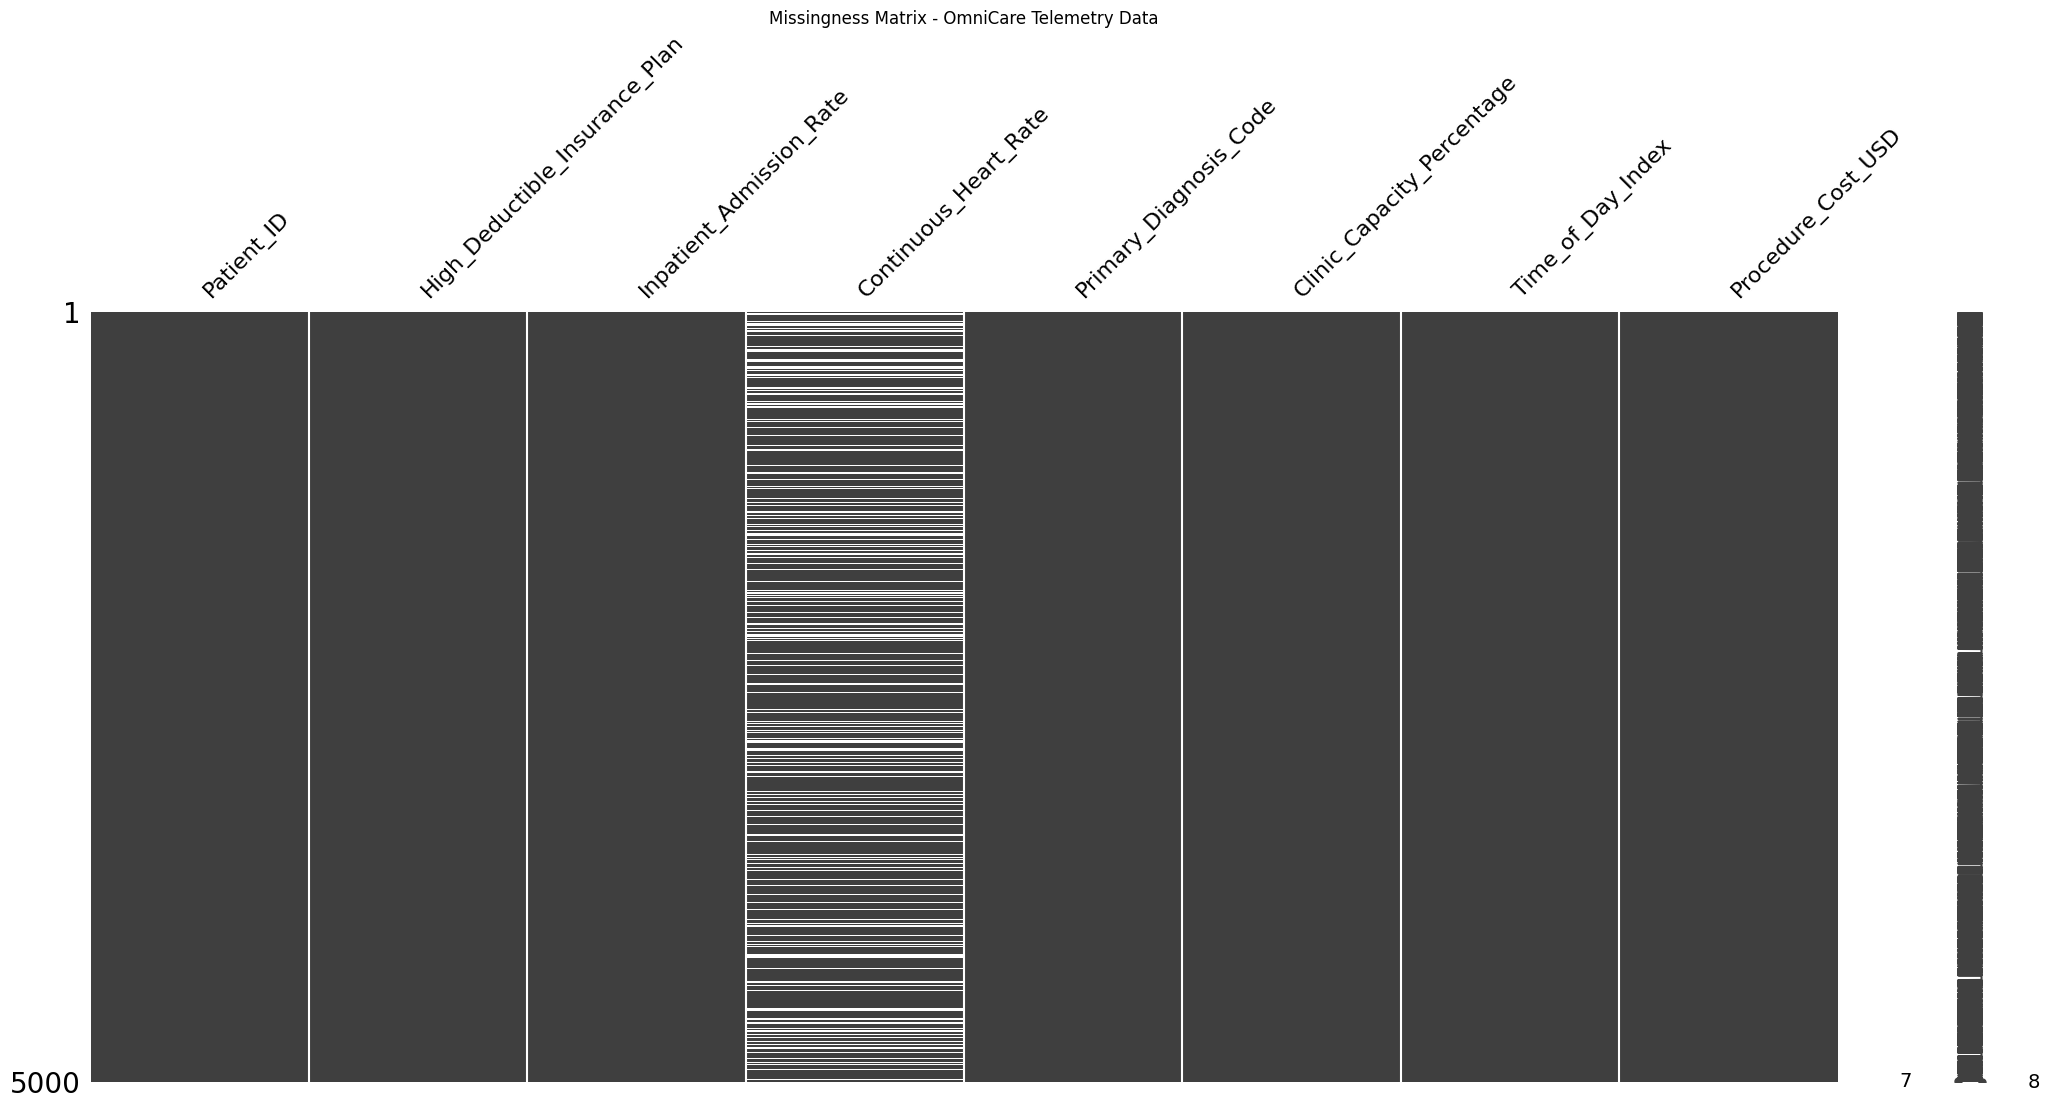

In [4]:


# Step 2.1

df_tele = pd.read_csv("OmniCare_Telemetry_Data.csv")

msno.matrix(df_tele)
plt.title("Missingness Matrix - OmniCare Telemetry Data")
plt.show()




Analysis: the gaps in Continuous_Heart_Rate are MNAR (Missing Not At Random)
Rubin's taxonomy has three types:
   MCAR - missingness is completely random, has nothing to do with the data
   MAR  - missingness depends on other observed variables in the dataset
   MNAR - missingness depends on the missing value itself or something unobserved

 In this case low-income patients are skipping transmission because of data plan costs
 that means the decision to NOT send data is tied to their socioeconomic status
 which is unobserved in our dataset and is also correlated with their actual heart rate so the missingness is systematically related to something we cant see = MNAR why mean imputation would destroy the dataset:
if we fill in missing heart rate values with the column mean, we are replacing readings that belong to a specific group (low-income patients) with an average
that was calculated from a completely different group (patients who could afford
to stream). this makes the imputed values biased and not representative of the
people they belong to, which would make any model trained on this data unreliable


Step 2.2
Why one-hot encoding 850 ICD-10 codes breaks OLS:
when you one-hot encode a categorical variable with 850 categories you get 850 binary columns where every row has exactly one 1 and the rest are 0s that means if you add all 850 columns together you always get 1 for every row which is exactly the same as the intercept column (a column of all 1s) so the intercept = sum of all 850 dummy columns this means one column is a perfect linear combination of the others making the design matrix singular (non-invertible) OLS requires us to compute (X'X)^-1 but you cant invert a singular matrix
 so the estimator completely breaks down

In [8]:
# Step 2.3
df_vitals = pd.read_csv("OmniCare_Telemetry_Data.csv")

# The original code caused a KeyError because 'Primary_Diagnosis_Code' and 'Procedure_Cost_USD'
# are not present in df_vitals according to the kernel state.
# To debug, let's print the columns available in df_vitals:
print("Columns in df_vitals:", df_vitals.columns.tolist())


encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])
df_vitals["Target_Encoded_Diagnosis"] = encoder.fit_transform(
     df_vitals["Primary_Diagnosis_Code"],
     df_vitals["Procedure_Cost_USD"]
       )
print("First 5 rows of the target encoded diagnosis column:")
print(df_vitals[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis"]].head())

Columns in df_vitals: ['Patient_ID', 'High_Deductible_Insurance_Plan', 'Inpatient_Admission_Rate', 'Continuous_Heart_Rate', 'Primary_Diagnosis_Code', 'Clinic_Capacity_Percentage', 'Time_of_Day_Index', 'Procedure_Cost_USD']
First 5 rows of the target encoded diagnosis column:
  Primary_Diagnosis_Code  Target_Encoded_Diagnosis
0                J86.381               1707.697108
1                M29.789               1792.303198
2                E49.618               1730.334968
3                E66.244               1725.060944
4                J45.553               1801.821085


In [9]:
df_vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")
df_tele = pd.read_csv("OmniCare_Telemetry_Data.csv")

df = pd.merge(df_vitals, df_tele, on="Patient_ID")


encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])
df["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    df["Primary_Diagnosis_Code"],
    df["Procedure_Cost_USD"]
)


df = df.dropna(subset=[
    "Procedure_Cost_USD", "Target_Encoded_Diagnosis",
    "Clinic_Capacity_Percentage", "Time_of_Day_Index",
    "Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"
])


In [12]:
import statsmodels.formula.api as smf

# Step 3.1
formula = ("Procedure_Cost_USD ~ Target_Encoded_Diagnosis + "
           "Clinic_Capacity_Percentage + Time_of_Day_Index + "
           "Weight_kg + Height_cm + Systolic_BP + Diastolic_BP")

model = smf.ols(formula=formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          6.83e-296
Time:                        17:16:37   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [14]:
# Step 3.2
from statsmodels.tools.eval_measures import rmse

# calculate RMSE to express model error in actual dollars
predicted = model.fittedvalues
actual = df["Procedure_Cost_USD"]

error = rmse(actual, predicted)
print(f"\nRMSE: ${error:.2f}")


RMSE: $334.80



Analysis: an RMSE of $450 on a $1200 procedure means the model is off by about 37% on average which is way too high for a live pricing system operationally  - patients could be quoted wildly different prices for the same procedure depending on when they book, which destroys trust financially - the hospital could be consistently underpricing high-cost cases and losing hundreds of dollars per procedure, or overcharging patients and exposing themselves to refund liability from a regulatory standpoint the No Surprises Act requires hospitals to
provide accurate cost estimates upfront, a $450 margin of error would likely violate that and open the hospital up to federal penalties

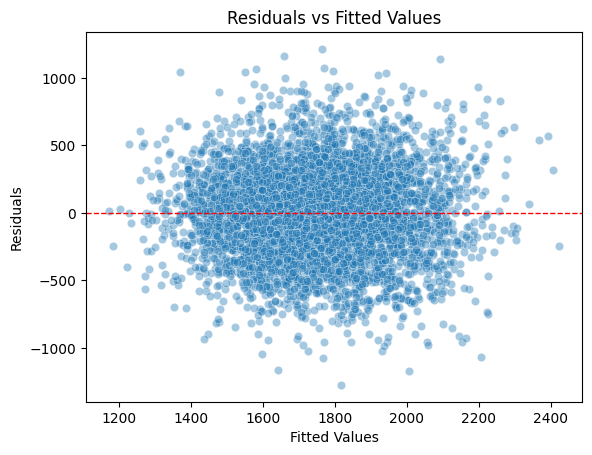

In [19]:
# Step 3.3
fitted = model.fittedvalues
residuals = model.resid
import seaborn as sns
import matplotlib.pyplot as plt

# plot residuals vs fitted values to check for heteroscedasticity
sns.scatterplot(x=fitted, y=residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Analysis: if the residuals fan out as fitted values increase (like a cone shape) that means the model makes bigger and bigger errors at higher price predictions this is heteroscedasticity and it violates a core OLS assumption for a surge pricing algorithm this is especially bad because the model is least reliable exactly when prices are highest, meaning the predictions that matter most financially are also the least trustworthy

Persona:
You are an expert econometrician and Python developer who specializes in statistical diagnostics for healthcare pricing models.

Role:
I am a data economist at OmniCare Analytics building a dynamic medical pricing algorithm using OLS regression. My model regresses Procedure_Cost_USD onto Target_Encoded_Diagnosis, Clinic_Capacity_Percentage, Time_of_Day_Index, Weight_kg, Height_cm, Systolic_BP, and Diastolic_BP using statsmodels.

Instructions:
Write a Python script that runs White's Lagrange Multiplier Test for Heteroscedasticity on my fitted OLS model. Use the het_white function from statsmodels.stats.diagnostic. The function takes the model residuals and the exogenous design matrix (model.model.exog) as inputs. Print the LM statistic and its p-value, then print a single concluding sentence stating whether the null hypothesis of homoscedasticity is rejected at the 0.05 significance level.

Meaning:
This test is critical because if heteroscedasticity is confirmed it means the OLS standard errors are unreliable, the pricing algorithm cannot be trusted at high cost tiers, and the model must be corrected before any live deployment.

Evaluation:
The output should clearly show the LM p-value as a float and the concluding sentence should explicitly reference the 0.05 threshold and state accepted or rejected in plain language.

In [20]:
from statsmodels.stats.diagnostic import het_white

lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(model.resid, model.model.exog)

print(f"LM Statistic: {lm_stat:.4f}")
print(f"LM p-value:   {lm_pvalue:.4f}")
print()

if lm_pvalue < 0.05:
    print(f"With a p-value of {lm_pvalue:.4f}, which is below the 0.05 significance "
          f"level, we reject the null hypothesis of homoscedasticity — the model "
          f"residuals exhibit statistically significant heteroscedasticity.")
else:
    print(f"With a p-value of {lm_pvalue:.4f}, which is above the 0.05 significance "
          f"level, we fail to reject the null hypothesis of homoscedasticity.")


LM Statistic: 186.4677
LM p-value:   0.0000

With a p-value of 0.0000, which is below the 0.05 significance level, we reject the null hypothesis of homoscedasticity — the model residuals exhibit statistically significant heteroscedasticity.
